In [8]:
import numpy as np 
import datetime as dt 
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd
import os
import matplotlib.dates as mdates


class TimeSeries:
  def __init__(self, data=None, log_returns = False):
    if log_returns:
      self.data = self.log_returns(data)
    else: self.data = np.array(data) if data is not None else np.array([])

  @staticmethod
  def log_returns(data):
    returns = data[data.columns[1]].pct_change()
    data[data.columns[1]] = np.log1p(returns).shift()
    return data

  def mean(self):
    return np.mean(self.data)
  
  def variance(self):
    pass

class index: 
  def __init__(self):
    pass



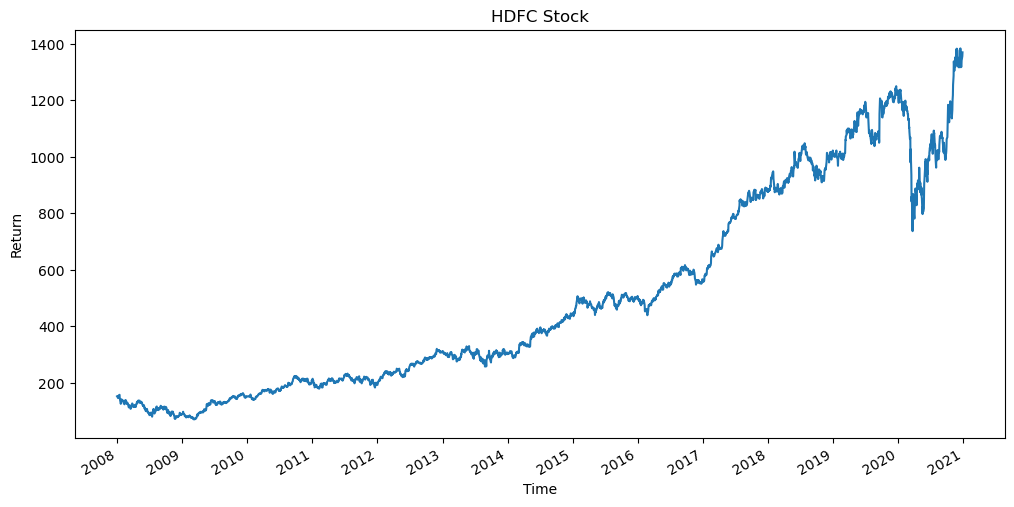

In [9]:
hdfc = TimeSeries(pd.read_csv('./workspace/notebooks/HDFCBANK.csv'))

dates = np.array([dt.datetime.strptime(date, '%Y-%m-%d') for date in hdfc.data[:, 0]])

plt.figure(figsize=(12, 6))

plt.plot(dates, hdfc.data[:,1], label="HDFC")
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()

plt.title("HDFC Stock")
plt.xlabel("Time")
plt.ylabel("Return")
plt.show()

In [10]:
hdfc_log = TimeSeries(pd.read_csv('./workspace/notebooks/HDFCBANK.csv'), True)
rel = TimeSeries(pd.read_csv('./workspace/notebooks/RELIANCE.csv'), True)
icici = TimeSeries(pd.read_csv('./workspace/notebooks/ICICIBANK.csv'), True)
artl = TimeSeries(pd.read_csv('./workspace/notebooks/BHARTIARTL.csv'), True)
tcs = TimeSeries(pd.read_csv('./workspace/notebooks/TCS.csv'), True)

In [11]:
hdfc_log.data.head()

,Date,HDFCBANK.NS
0,2008-01-01,NaN
1,2008-01-02,NaN
2,2008-01-03,-0.008244
3,2008-01-04,-0.012259
4,2008-01-07,0.001180


ValueError: The truth value of a DataFrame is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

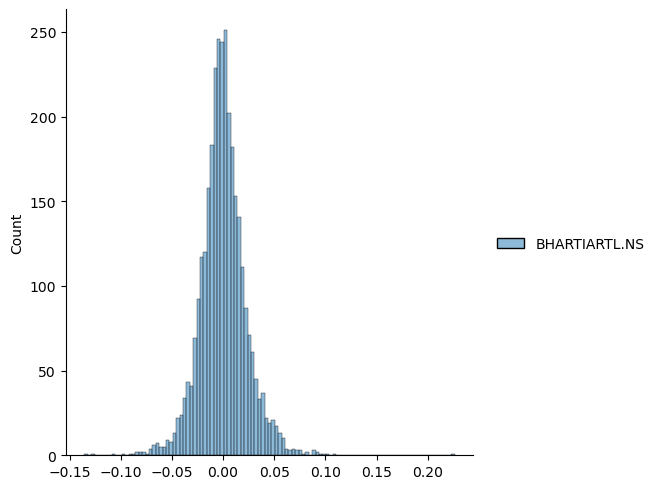

In [12]:
datasets = [hdfc_log, rel, icici, artl, tcs]
titles = ['HDFC', 'REL', 'ICICI', 'ARTL', 'TCS']
sns.displot(artl.data, kde_kws={"color":"b","lw":1,"label":"HDFC Log"})
sns.displot([rel.data, tcs.data], kde_kws={"color":"b","lw":1,"label":"Reliance"})
sns.displot([icici.data, hdfc_log.data], kde_kws={"color":"b","lw":1,"label":"HDFC Log"})

plt.tight_layout()
plt.show()

In [13]:
print(np.shape(dates), np.shape(hdfc_log.data), np.shape(rel.data), np.shape(icici.data), np.shape(rel.data))
log_returns = pd.concat([
    hdfc_log.data.set_index('Date'),
    rel.data.set_index('Date'),
    icici.data.set_index('Date'),
    artl.data.set_index('Date'),
    tcs.data.set_index('Date')
], axis=1)
log_returns = log_returns.iloc[2:]
log_returns.head()

(3200,) (3200, 2) (3200, 2) (3200, 2) (3200, 2)


,HDFCBANK.NS,RELIANCE.NS,ICICIBANK.NS,BHARTIARTL.NS,TCS.NS
Date,,,,,
2008-01-03,-0.008244,0.004729,0.030851,-0.001396,-0.004324
2008-01-04,-0.012259,0.014553,-0.030689,-0.017909,-0.037801
2008-01-07,0.001180,0.030290,0.045610,-0.000790,-0.005803
2008-01-08,-0.024466,0.009064,0.057588,-0.011987,-0.029889
2008-01-09,0.035808,0.011325,-0.016726,0.040624,0.012478


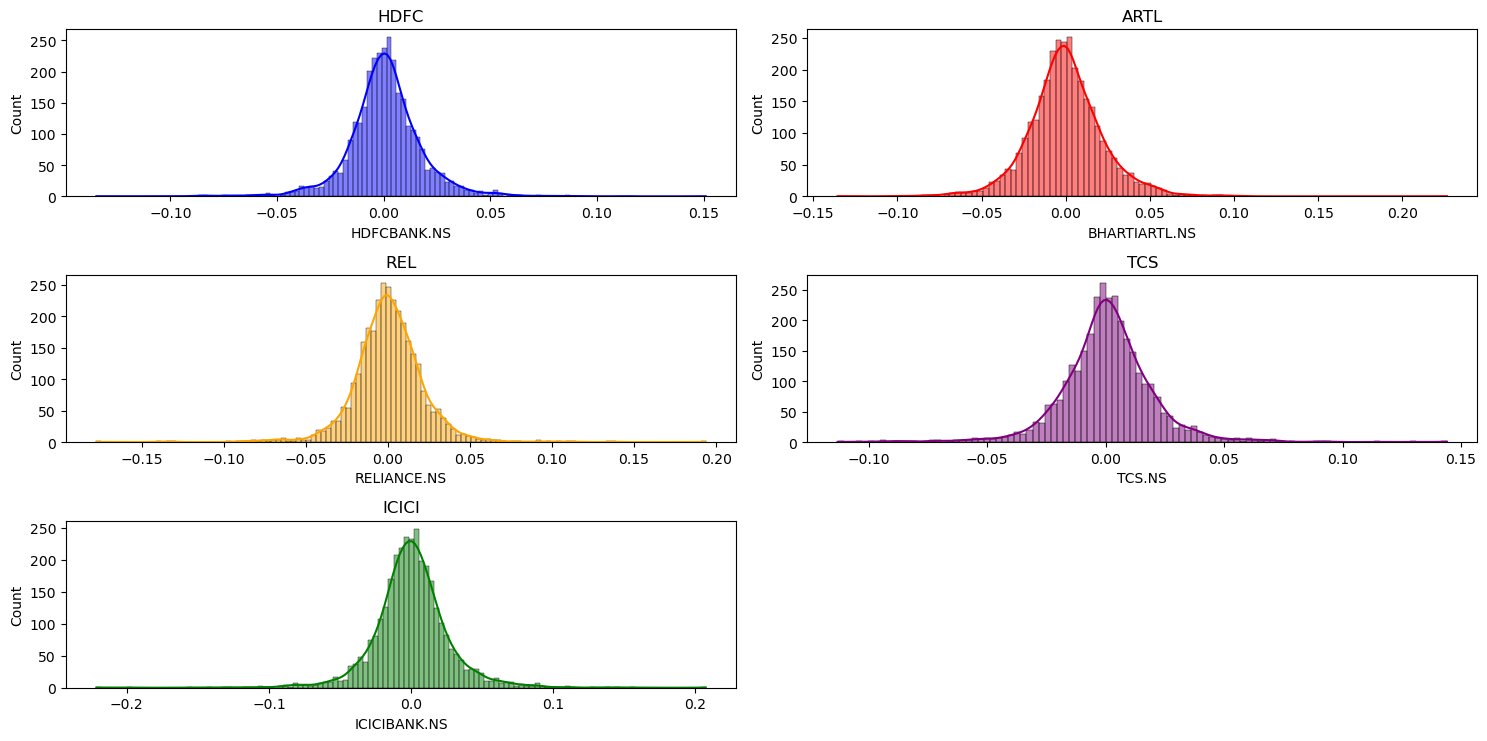

In [14]:
fig = plt.figure(figsize=(15, 12))
colors = ['blue', 'orange', 'green', 'red', 'purple']

for i in range(3):
    ax = plt.subplot2grid((5, 2), (i, 0))  # First column
    sns.histplot(log_returns.iloc[:, i], kde=True, ax=ax, color=colors[i])
    ax.set_title(titles[i])


for j in range(2):
    ax = plt.subplot2grid((5, 2), (j, 1))  # Second column
    sns.histplot(log_returns.iloc[:, 3 + j], kde=True, ax=ax, color=colors[3 + j])
    ax.set_title(titles[3 + j])

plt.tight_layout()
plt.show()


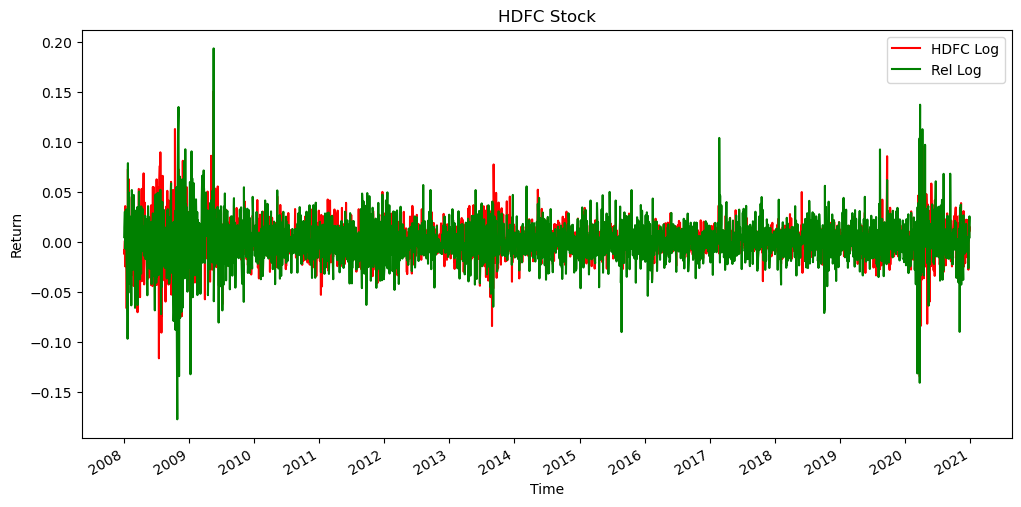

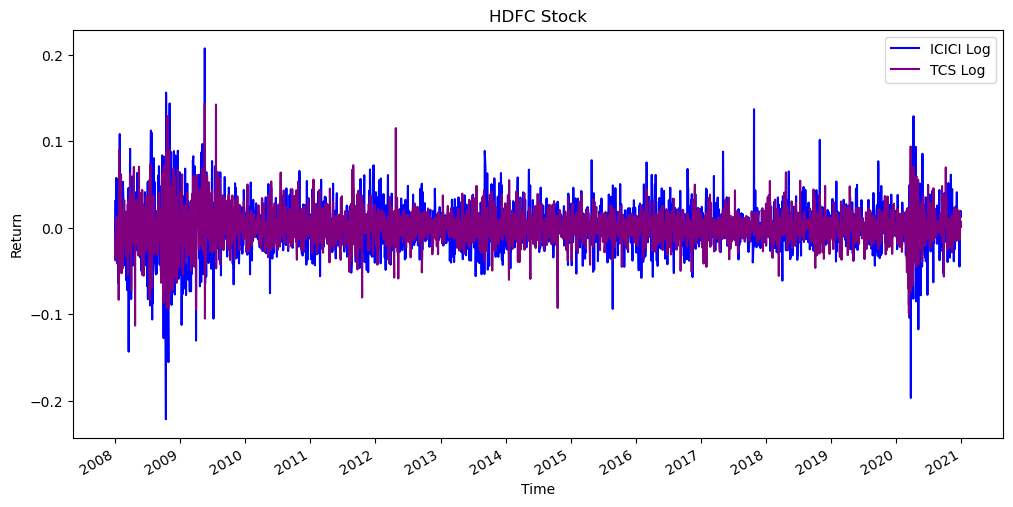

In [49]:
plt.figure(figsize=(12, 6))

sns.lineplot(x=dates, y=hdfc_log.data.iloc[:,1], label="HDFC Log", color='red')
sns.lineplot(x=dates, y=rel.data.iloc[:,1], label="Rel Log", color='green')


plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()

plt.title("HDFC Stock")
plt.xlabel("Time")
plt.ylabel("Return")
plt.show()

plt.figure(figsize=(12, 6))

sns.lineplot(x=dates, y=icici.data.iloc[:,1], label="ICICI Log", color='blue')
sns.lineplot(x=dates, y=tcs.data.iloc[:,1], label="TCS Log", color='purple')
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()

plt.title("HDFC Stock")
plt.xlabel("Time")
plt.ylabel("Return")
plt.show()

In [18]:
import sktime
from statsmodels.tsa.stattools import adfuller

In [20]:
hdfc_log.data

,Date,HDFCBANK.NS
0,2008-01-01,NaN
1,2008-01-02,NaN
2,2008-01-03,-0.008244
3,2008-01-04,-0.012259
4,2008-01-07,0.001180
...,...,...
3195,2020-12-22,-0.027803
3196,2020-12-23,0.000328
3197,2020-12-24,0.001855
3198,2020-12-28,0.015472


In [25]:
# Test for stationarity 
adf_result = adfuller(hdfc_log.data.iloc[2:,1])
print('ADF statistic: ', adf_result[0], '\np-value: ', adf_result[1])

adf_result = adfuller(rel.data.iloc[2:,1])
print('ADF statistic: ', adf_result[0], '\np-value: ', adf_result[1])

adf_result = adfuller(artl.data.iloc[2:,1])
print('ADF statistic: ', adf_result[0], '\np-value: ', adf_result[1])

ADF statistic:  -13.084477035117018 
p-value:  1.841896300578004e-24
ADF statistic:  -31.05193501870278 
p-value:  0.0
ADF statistic:  -36.16125843032287 
p-value:  0.0


In [ ]:
# GARCH implementation and the volatility clustering animations

class GARCH: 
  def __init__(self):
    pass
  

In [ ]:
from numba import jit

class GARCH: # garch(1,1)
    def __init__(self, omega, alpha, beta, returns):
        self.omega = omega
        self.alpha = alpha
        self.beta = beta
        self.returns = returns
        self.volatility = TimeSeries()

    @jit(nopython=True)  # JIT compile for speed
    def _simulate_core(self, returns, omega, alpha, beta):
        n = len(returns)
        volatility = np.zeros(n)
        volatility[0] = np.var(returns) 
        for t in range(1, n):
            volatility[t] = omega + alpha * returns[t-1]**2 + beta * volatility[t-1]
        return volatility

    def simulate(self):
        self.volatility.data = self._simulate_core(self.returns.data, 
                                                  self.omega, self.alpha, self.beta)
        return self.volatility

# Run GARCH
garch = GARCH(omega=0.0001, alpha=0.1, beta=0.85, returns=returns)
volatility = garch.simulate()

# Graphing
plt.plot(volatility.data, label="Volatility", color="orange")
plt.title("GARCH(1,1) Volatility")
plt.xlabel("Time")
plt.ylabel("Variance")
plt.legend()
plt.show()

NameError: name 'returns' is not defined

In [51]:
import sys
print(sys.executable)

/Users/amadika/miniconda3/bin/python


In [54]:
!python --version
print(np.__file__)

Python 3.8.11
/Users/amadika/miniconda3/lib/python3.8/site-packages/numpy/__init__.py


In [3]:
import llvmlite
print(llvmlite.__file__)
print(numba.__file__)


/Users/amadika/miniconda3/lib/python3.8/site-packages/llvmlite/__init__.py


NameError: name 'numba' is not defined

vol surface for pricing, options: volatility of retail options with game theory